##Preparação/importação



In [2]:
#Importações

import pandas as pd
import numpy as np
import re
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler
import nltk
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
#importa CSV do scrap
decisoes_df = pd.DataFrame()



arquivo = 'https://github.com/mbardela/ementas_tit/raw/refs/heads/main/ementas_tit.csv'

decisoes_df = pd.read_csv(arquivo, sep=';', encoding='utf8')

#renomeia algumas colunas do scrap e ajusta dtype, etc

decisoes_df.rename(columns={'Ementa': 'ementa'}, inplace=True)
decisoes_df.rename(columns={'Data da Publicação': 'data_pub'}, inplace=True)

decisoes_df['data_pub'] = pd.to_datetime(decisoes_df['data_pub'], format='%d/%m/%Y')
decisoes_df['ano_pub'] = decisoes_df['data_pub'].dt.year

# Extrai os 7 primeiros dígitos da coluna 'AIIM' e converte para integer
decisoes_df['AIIM_int'] = pd.to_numeric(decisoes_df['AIIM'].astype(str).str.replace(r'\D', '', regex=True).str[:7], errors='coerce').fillna(0).astype(int)

decisoes_df.dropna(inplace=True)

display(decisoes_df.info())
display(decisoes_df)

<class 'pandas.core.frame.DataFrame'>
Index: 36701 entries, 0 to 37092
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Nome da Origem  36701 non-null  object        
 1   data_pub        36701 non-null  datetime64[ns]
 2   Recurso         36701 non-null  object        
 3   DRT             36701 non-null  object        
 4   Processo        36701 non-null  int64         
 5   Ano             36701 non-null  int64         
 6   AIIM            36701 non-null  object        
 7   ementa          36701 non-null  object        
 8   ano_pub         36701 non-null  int32         
 9   AIIM_int        36701 non-null  int64         
dtypes: datetime64[ns](1), int32(1), int64(3), object(5)
memory usage: 2.9+ MB


None

,Nome da Origem,data_pub,Recurso,DRT,Processo,Ano,AIIM,ementa,ano_pub,AIIM_int
0,ementas_tit_2015-01.csv,2015-01-08,ORDINARIO,11,3161064,2011,3161064-0,AIIM ICMS - ACUSAÇÃO DE RECEBIMENTO DE CRÉDITO...,2015,3161064
1,ementas_tit_2015-01.csv,2015-01-16,ORDINARIO,1C,4029507,2013,4029507-2,Falta de pagamento do imposto referente ao sal...,2015,4029507
2,ementas_tit_2015-01.csv,2015-01-16,ORDINARIO,16,164605,2010,3129058-9,ICMS. Crédito indevido. Documento inidôneo. In...,2015,3129058
3,ementas_tit_2015-01.csv,2015-01-16,ORDINARIO,12,176690,2010,3128037-7,ICMS. Falta de pagamento do ICMS apurada por m...,2015,3128037
4,ementas_tit_2015-01.csv,2015-01-16,ORDINARIO,06,3157786,2011,3157786-6,ICMS – creditamento indevido – falta de compro...,2015,3157786
...,...,...,...,...,...,...,...,...,...,...
37088,ementas_tit_2025-12.csv,2025-12-22,ORDINARIO,14,5051047,2024,5051047-2,ICMS – Discussão Judicial do AIIM – Renúncia à...,2025,5051047
37089,ementas_tit_2025-12.csv,2025-12-22,ORDINARIO,UGC,5050805,2024,5050805-2,ITCMD - FALTA DE PAGAMENTO DE IMPOSTO NO RECEB...,2025,5050805
37090,ementas_tit_2025-12.csv,2025-12-22,ESPECIAL,10,61847,2009,3106590-9,ICMS - Diversas Infrações (falta de pagamento ...,2025,3106590
37091,ementas_tit_2025-12.csv,2025-12-22,RETIFICACAO,09,4130102,2019,4130102-0,ITCMD. PEDIDO DE\nRETIFICAÇÃO DE JULGADO. ERRO...,2025,4130102


Padronizando texto das ementas (tirando quebra de linha, tab...)

In [4]:
def clean_text(text):
    if pd.isna(text):
        return ''
    text = text.replace('\t', ' ')
    text = text.replace('\n', ' ')
    text = text.replace('\r', ' ')
    text = re.sub(r'\s+', ' ', text).strip()
    return text.lower()

decisoes_df['ementa'] = decisoes_df['ementa'].apply(clean_text)

#display
decisoes_df.info()
display(decisoes_df.head())

<class 'pandas.core.frame.DataFrame'>
Index: 36701 entries, 0 to 37092
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Nome da Origem  36701 non-null  object        
 1   data_pub        36701 non-null  datetime64[ns]
 2   Recurso         36701 non-null  object        
 3   DRT             36701 non-null  object        
 4   Processo        36701 non-null  int64         
 5   Ano             36701 non-null  int64         
 6   AIIM            36701 non-null  object        
 7   ementa          36701 non-null  object        
 8   ano_pub         36701 non-null  int32         
 9   AIIM_int        36701 non-null  int64         
dtypes: datetime64[ns](1), int32(1), int64(3), object(5)
memory usage: 2.9+ MB


,Nome da Origem,data_pub,Recurso,DRT,Processo,Ano,AIIM,ementa,ano_pub,AIIM_int
0,ementas_tit_2015-01.csv,2015-01-08,ORDINARIO,11,3161064,2011,3161064-0,aiim icms - acusação de recebimento de crédito...,2015,3161064
1,ementas_tit_2015-01.csv,2015-01-16,ORDINARIO,1C,4029507,2013,4029507-2,falta de pagamento do imposto referente ao sal...,2015,4029507
2,ementas_tit_2015-01.csv,2015-01-16,ORDINARIO,16,164605,2010,3129058-9,icms. crédito indevido. documento inidôneo. in...,2015,3129058
3,ementas_tit_2015-01.csv,2015-01-16,ORDINARIO,12,176690,2010,3128037-7,icms. falta de pagamento do icms apurada por m...,2015,3128037
4,ementas_tit_2015-01.csv,2015-01-16,ORDINARIO,06,3157786,2011,3157786-6,icms – creditamento indevido – falta de compro...,2015,3157786


##Carregado e limpo o csv, passamos ao processamento das ementas

stopwords + stemming (NLTK)


In [5]:
nltk.download('rslp')
nltk.download('stopwords')
stopwords = nltk.corpus.stopwords.words('portuguese')

stemmer = nltk.stem.RSLPStemmer()

stopwords_ajustado = ['aiim','fiscal','icms','recurso','ordinário','ofício','especial','recorreu','súmula','decreto','portaria',
                      'julgamento','auto','autos','mantido','provido','provimento','conhecido','conhecimento','parcialmente',
                      'negou','não','convertido','conversão','item','itens','nulidade','determinado','tributário'
                      'de','da','aplicação','lei','nº','artigo','art','imposto','superior','câmara',
                      'ricms','decisão','contribuinte','recorrente','recorrida','recorrido','tit','sp','tribunal','estado','paulo',
                      'infrações','fazenda','pública','autuada','multa',
                      'i','ii','iii','iv','v','vi','vii','viii','ix','x','xi','xii','xiii','xiv','xv','xvi','xvii','xviii','xix','xx',
                      'um','dois','três','quatro','cinco','seis','sete','oito','nove','dez',
                      'cem','mil','milhão','milhões'
                      ]

# adiciona as stopwords específicas de domínio no stopwords default do NLTK
stopwords_ajustado.extend(stopwords)

# Função para criar ementa_clean (limpeza de regex e stopwords)
def clean_and_filter(texto):
    # Divide o texto em palavras
    itens = texto.split(' ')
    palavras_filtradas = []

    for palavra in itens:
        # Mantém apenas letras e caracteres acentuados usando regex
        palavra_limpa = re.sub(r'[^a-zA-ZáàâãéèêíïóôõöúçñÁÀÂÃÉÈÊÍÏÓÔÕÖÚÇÑ]', '', palavra).lower()

        # Filtra se não estiver vazia e não for stopword
        if palavra_limpa.strip() and palavra_limpa not in stopwords_ajustado:
            palavras_filtradas.append(palavra_limpa)

    return ' '.join(palavras_filtradas)

# Função para stemming a partir do texto limpo
def apply_stemming(texto_limpo):
    itens = texto_limpo.split(' ')
    l_palavras = [stemmer.stem(p) for p in itens if p]
    return ' '.join(l_palavras)

# Cria a coluna ementa_clean primeiro
decisoes_df['ementa_clean'] = decisoes_df['ementa'].apply(clean_and_filter)

# Cria ementa_stem a partir da ementa_clean
decisoes_df['ementa_stem'] = decisoes_df['ementa_clean'].apply(apply_stemming)

[nltk_data] Downloading package rslp to /root/nltk_data...
[nltk_data]   Unzipping stemmers/rslp.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [6]:
#compara texto original e stemmerizado"
print(decisoes_df.loc[50, 'ementa_clean'])
print("---------------------------")
print(decisoes_df.loc[50, 'ementa_stem'])

deixar exibir autoridade fiscalizadora prazo cominado notificações específicas tal fim impressos documentos fiscais modelo série n ns deixar exibir autoridade fiscalizadora prazo cominado notificações específicas tal fim livros fiscais livro registro entradas relativo exercícios livros livro registro saidas relativo exercícios livros livro registro utilização documentos fiscais termo ocorrências modelo promover encerramento atividades estabelecimento comunicar fato repartição vinculado improvido mantendose integralmente
---------------------------
deix exib autoridad fiscaliz praz comin notific específ tal fim impress document fiscal model séri n ns deix exib autoridad fiscaliz praz comin notific específ tal fim livr fiscal livr registr entr relat exercíci livr livr registr said relat exercíci livr livr registr utiliz document fiscal term ocorr model promov encerr ativ estabelec comunic fat repart vincul improv mantendos integr


1. Ver distribuição de palavras inteiras nas ementas (extremos)

In [7]:
# Adiciona contagem de palavras da coluna "ementa_clean" em decisoes_df na coluna 'ementa_word_count'

decisoes_df['ementa_word_count'] = decisoes_df['ementa_clean'].apply(lambda x: len(x.split(' ')))

# Filtragem
# exploração iterativa
# parece que <10 é só diligência ou lixo

i=7
ementas_filtrado = decisoes_df[decisoes_df['ementa_word_count'] < i]

#display(ementas_filtrado)





In [8]:
# da exploração do dataset acima, temos um número grande diligências. iremos expurgar
# Lista de termos para exclusão
termos_excluir = ['conversão do julgamento em diligência', 'convertido em diligência', 'conversão em diligência']

# Cria um padrão regex unindo os termos com o operador OR (|)
padrao_exclusao = '|'.join(termos_excluir)

# Filtra o dataframe mantendo apenas o que não contém os termos
decisoes_df = decisoes_df[~decisoes_df['ementa'].str.contains(padrao_exclusao, case=False, na=False)]

# Verifica o resultado

#display(ementas_filtrado)

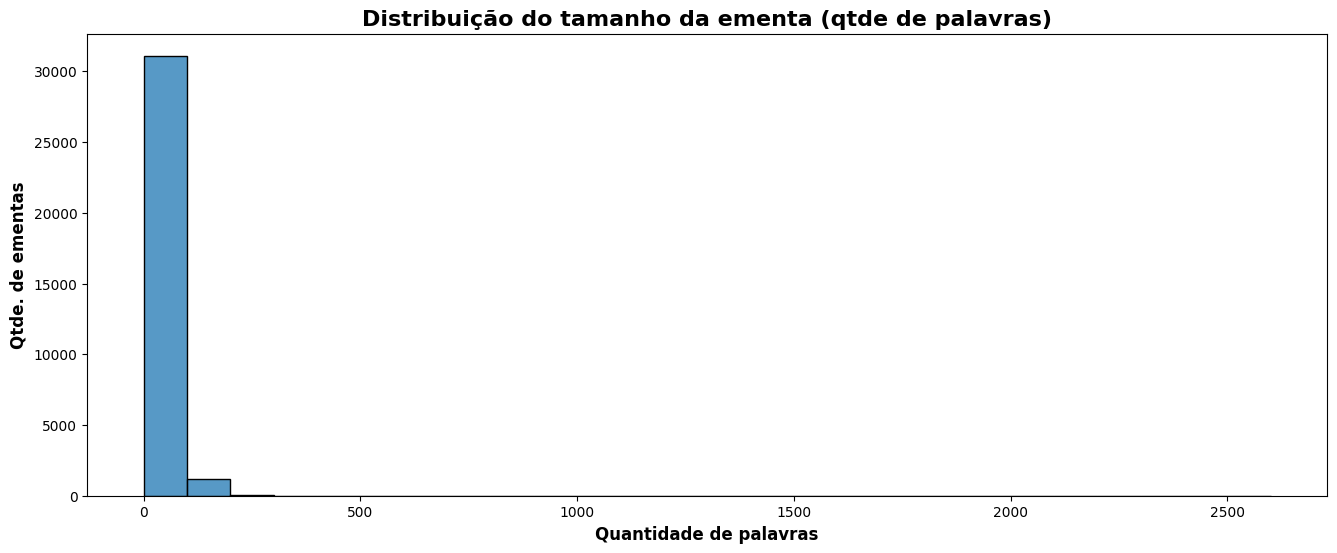

In [9]:
#histograma de contagem de palavras em 'ementa'

max_word_count = decisoes_df['ementa_word_count'].max()
bins = np.arange(0, max_word_count + 100, 100)

fig, ax = plt.subplots(figsize=(16, 6))
sns.histplot(decisoes_df['ementa_word_count'], bins=bins, kde=False)
plt.title('Distribuição do tamanho da ementa (qtde de palavras)', fontsize=16, fontweight='bold')
ax.set_xlabel('Quantidade de palavras', fontsize=12, fontweight='bold')
ax.set_ylabel('Qtde. de ementas', fontsize=12, fontweight='bold')
plt.xticks(bins[::5])
plt.show()

In [10]:
# gráfico de distribuição long tail
# analisar extremos superiores

# Define os limites dos bins
i_bin =50
max_words = decisoes_df['ementa_word_count'].max()
bins = list(range(0, int(max_words) + i_bin, i_bin))

# Cria as categorias e conta as ocorrências
decisoes_df['bins_texto'] = pd.cut(decisoes_df['ementa_word_count'], bins=bins)
contagem_bins = decisoes_df['bins_texto'].value_counts().sort_index().reset_index()
contagem_bins.columns = ['Intervalo (Qtd. Palavras)', 'Total de Ementas']

# Calcula o total geral de ementas
total_geral_ementas = contagem_bins['Total de Ementas'].sum()

# Adiciona a coluna com o percentual do total
contagem_bins['% do Total'] = (contagem_bins['Total de Ementas'] / total_geral_ementas * 100).round(2)

# Exibe o resultado formatado como texto/tabela
display(contagem_bins)

,Intervalo (Qtd. Palavras),Total de Ementas,% do Total
0,"(0, 50]",25599,79.25
1,"(50, 100]",5546,17.17
2,"(100, 150]",1001,3.10
3,"(150, 200]",128,0.40
4,"(200, 250]",10,0.03
5,"(250, 300]",10,0.03
6,"(300, 350]",2,0.01
7,"(350, 400]",1,0.00
8,"(400, 450]",1,0.00
9,"(450, 500]",0,0.00


In [11]:
#da exploração acima, vamos podar > 250 palavras
decisoes_df = decisoes_df[decisoes_df['ementa_word_count'] <= 150]

# Resetar o índice para garantir alinhamento com a matriz TF-IDF
decisoes_df.reset_index(drop=True, inplace=True)

print(f"Número de ementas após a poda: {len(decisoes_df)}")


Número de ementas após a poda: 32146


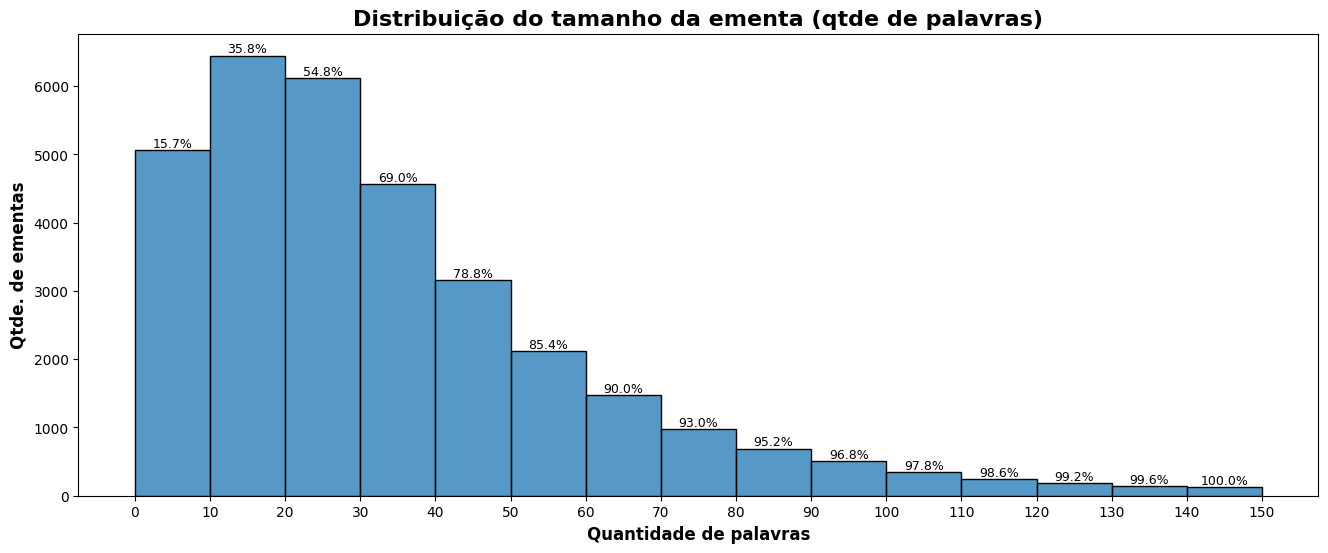

In [12]:
#repete o histograma, agora mais detalhado
i_bin =10
max_word_count = decisoes_df['ementa_word_count'].max()
bins = np.arange(0, max_word_count + i_bin, i_bin)

fig, ax = plt.subplots(figsize=(16, 6))
hist_plot = sns.histplot(decisoes_df['ementa_word_count'], bins=bins, kde=False, ax=ax)
plt.title('Distribuição do tamanho da ementa (qtde de palavras)', fontsize=16, fontweight='bold')
ax.set_xlabel('Quantidade de palavras', fontsize=12, fontweight='bold')
ax.set_ylabel('Qtde. de ementas', fontsize=12, fontweight='bold')
plt.xticks(bins[::1])

# Adiciona o percentual acumulado em cada barra
total_ementas = len(decisoes_df)

# Get the counts for each bin from the hist_plot.patches
counts = [p.get_height() for p in hist_plot.patches]
cumulative_counts = np.cumsum(counts)
cumulative_percentages = (cumulative_counts / total_ementas) * 100

for i, p in enumerate(hist_plot.patches):
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    # Only annotate if there's a bar (y > 0)
    if y > 0:
        percentage = '{:.1f}%'.format(cumulative_percentages[i])
        ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=9, color='black')

plt.show()

BAG OF WORDS (stems únicos)


In [13]:
#Uso do CountVectorizer para criar uma BoW - contagem de stems únicos e análise exploratória

CV = CountVectorizer()
matriz_contagens_stem = CV.fit_transform(decisoes_df['ementa_stem'])

matriz_contagens_stem

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 898256 stored elements and shape (32146, 13522)>

In [14]:
#Cria um dicionário de palavras para a coluna "ementa_stem" do DataFrame

df_word_dict = pd.DataFrame(CV.get_feature_names_out(), columns = ['stem'])
df_word_dict['vezes_que_aparece'] = matriz_contagens_stem.sum(axis = 0).tolist()[0]
df_word_dict = df_word_dict.sort_values("vezes_que_aparece", ascending = False) # Ordena as linhas do dataframe
pd.set_option('display.max_rows', 20)
df_word_dict[0:20]

,stem,vezes_que_aparece
2830,crédit,19542
5425,fiscal,17132
9366,pag,16605
8238,mercad,15645
5202,falt,15543
3950,document,14308
9171,oper,13622
6668,indev,13167
8838,not,10704
4686,escritur,9572


In [15]:
unique_words = df_word_dict['stem'].nunique()
print("Número de stems únicas na coluna 'ementa_stem':", unique_words)

Número de stems únicas na coluna 'ementa_stem': 13522


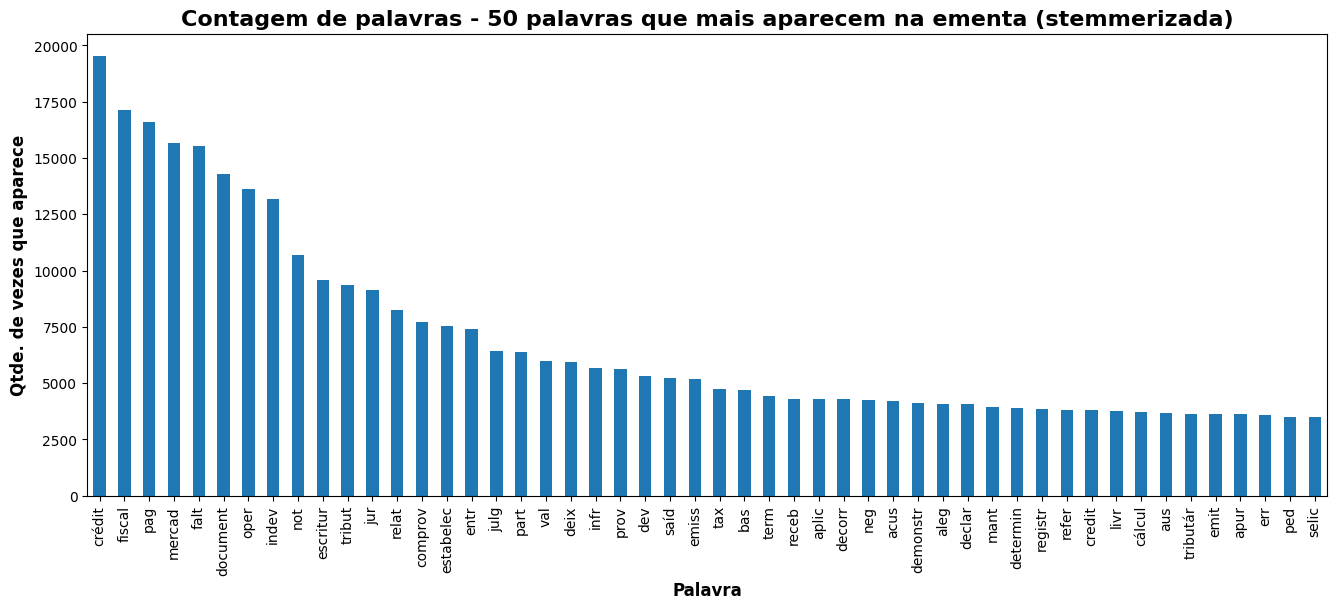

In [16]:
fig, ax = plt.subplots(figsize=(16, 6))
# Plotando apenas as 50 primeiras palavras
df_word_dict['vezes_que_aparece'][0:50].plot(kind = 'bar')
plt.title('Contagem de palavras - 50 palavras que mais aparecem na ementa (stemmerizada)', fontsize = 16, fontweight = 'bold')
# Ajustando as etiquetas para serem apenas as 50 palavras correspondentes
ax.set_xticklabels(df_word_dict['stem'][0:50])
ax.set_xlabel('Palavra', fontsize = 12, fontweight = 'bold')
ax.set_ylabel('Qtde. de vezes que aparece', fontsize = 12, fontweight = 'bold')
plt.show()

--Fim do pré-processamento--
# Início do ML



##1a parte - baseline
TF-IDF + Cluster
*italicized text*

In [17]:
#Vetorização através do TFIDFVectorizer do SciKit-Learn

# Gerar uma nova lista de stopwords stemizadas para o TfidfVectorizer
stopwords_ajustado_stemmed = [stemmer.stem(word) for word in stopwords_ajustado]

# Remover duplicatas que podem surgir da stemização (ex: 'recurso' e 'recursos' viram 'recurs')
stopwords_ajustado_stemmed = list(set(stopwords_ajustado_stemmed))

#mf = int(unique_words * 0.8)
vectorizer = TfidfVectorizer(stop_words = stopwords_ajustado_stemmed)#, min_df = 1) #, max_features=mf)
matriz_tfidf_ementa = vectorizer.fit_transform(decisoes_df['ementa_stem'])

df_matriz_tfidf_ementa = pd.DataFrame(matriz_tfidf_ementa.toarray(), columns = vectorizer.get_feature_names_out())
pd.set_option('display.max_rows', 10)

df_matriz_tfidf_ementa

,aa,aab,aald,ab,abaix,abaixoement,abal,abarc,abast,abastastec,...,ôle,ônibu,ônu,õe,õnu,últ,únic,únicoiv,útel,útil
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.343821,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32141,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
32142,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
32143,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
32144,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0


In [18]:
#EXPLORATÓRIA --> Ver se faz sentido a matriz acima#
###################################################

# Seleciona um registro de índice da matriz TF-IDF
row_index = 7228
document_vector = df_matriz_tfidf_ementa.iloc[row_index]

# Filtra os termos com scores TF-IDF maiores que zero
non_zero_terms = document_vector[document_vector > 0]

# Cria um DataFrame para melhor visualização e ordena pelos scores TF-IDF
df_document_terms = pd.DataFrame({
    'Termo': non_zero_terms.index,
    'TF-IDF Score': non_zero_terms.values
}).sort_values(by='TF-IDF Score', ascending=False)

print(f"Stems e seus scores TF-IDF para a ementa no índice {row_index} (somente termos != 0):")
display(df_document_terms)

print(f"\nEmentas correspondente ao índice {row_index}:")
print("-----pura")
display(decisoes_df.loc[row_index, 'ementa'])
print("-----clean")
display(decisoes_df.loc[row_index, 'ementa_clean'])
print("-----stem")
display(decisoes_df.loc[row_index, 'ementa_stem'])



Stems e seus scores TF-IDF para a ementa no índice 7228 (somente termos != 0):


,Termo,TF-IDF Score
0,aa,0.266294
7,cobilling,0.266294
29,parcialemt,0.266294
1,ab,0.258841
6,cat,0.222035
...,...,...
4,bas,0.081641
16,estabelec,0.070447
34,relat,0.069183
19,jur,0.064171



Ementas correspondente ao índice 7228:
-----pura


'icms – deixar de transmitir eletronicamente à secretaria da fazenda, no prazo estabelecido no art. 6º da portaria cat 79/03, antes de iniciada ação fiscal determinada em ordem de serviço fiscal (osf) - nfst relativas ao faturamento conjunto (cobilling) com outras prestadoras - deixar de registrar em meio magnético notas fiscais de serviço de telecomunicações, modelo 22, das séries “aa” e “ab”, contrariando as disposições do § 2º do art. 4º da portaria cat 79/03. erro na capitulação da multa. juros de mora não compõem a base de cálculo da multa. recurso ordinário conhecido e parcialemte provido para recapitular a multa dos itens 3 e 4 do aiim. mantidos os itens 1 e 2 aiim.'

-----clean


'deixar transmitir eletronicamente secretaria prazo estabelecido cat antes iniciada ação determinada ordem serviço osf nfst relativas faturamento conjunto cobilling outras prestadoras deixar registrar meio magnético notas fiscais serviço telecomunicações modelo séries aa ab contrariando disposições cat erro capitulação juros mora compõem base cálculo parcialemte recapitular mantidos'

-----stem


'deix transmit eletronic secret praz estabelec cat ant inici açã determin ord serviç osf nfst relat fatur conjunt cobilling outr prest deix registr mei magné not fiscal serviç telecomunic model séri aa ab contrari dispos cat err capitul jur mor compõ bas cálcul parcialemt recapitul mant'

In [19]:
# Reduzindo a dimensionalidade (maldição da hiper dimensionalidade)
# Usando SVD para diminuir a dimensionalidade

svd = TruncatedSVD(n_components = 100, n_iter = 7, random_state = 1)
matriz_tfidf_ementa_svd = svd.fit_transform(df_matriz_tfidf_ementa)
df_matriz_tfidf_ementa_svd = pd.DataFrame(matriz_tfidf_ementa_svd)
df_matriz_tfidf_ementa_svd

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,0.013526,0.164995,0.018228,0.068742,-0.031376,-0.012568,-0.012003,-0.095607,-0.027148,0.008709,...,0.038197,0.034387,-0.010120,-0.007241,0.009779,-0.007138,0.043568,0.019166,-0.007456,0.004930
1,0.046351,0.198656,-0.029837,0.065308,0.024486,0.131128,0.003798,-0.112193,0.001726,0.048562,...,-0.042604,0.019316,0.088096,-0.034075,0.010186,0.020279,-0.013737,-0.025281,-0.000091,-0.011133
2,0.063248,0.171970,0.186385,0.020866,0.039840,0.036754,-0.057813,0.068013,-0.002172,0.021359,...,-0.003262,-0.076705,0.047546,-0.031694,-0.015153,-0.033332,-0.012651,0.011010,0.049275,0.074294
3,0.046021,0.210435,-0.043132,0.132622,0.059888,-0.043243,-0.053461,0.022990,-0.039596,0.033203,...,-0.042333,0.031572,-0.043793,0.006481,-0.039257,0.012072,-0.059190,0.071469,-0.076900,-0.031430
4,0.015243,0.184419,0.005177,0.012166,0.120941,0.080481,-0.111490,0.010498,0.074810,-0.009193,...,-0.038202,-0.021902,-0.050439,-0.020083,0.011258,-0.035097,0.033630,0.015495,-0.027688,0.000281
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32141,0.004222,0.038586,-0.026579,0.044497,0.008955,-0.004451,-0.047414,-0.050023,-0.013483,0.084731,...,0.020682,0.022768,0.075213,0.056930,-0.069065,-0.006670,-0.052952,0.098492,-0.036581,-0.023051
32142,0.008485,0.098371,-0.050193,0.036974,-0.007034,-0.001939,-0.104645,-0.003161,-0.020044,0.064217,...,-0.004788,-0.011621,0.016862,0.023751,-0.052173,0.001672,-0.001417,-0.016824,-0.008469,-0.014715
32143,0.016361,0.202101,0.007299,0.093620,0.037064,-0.035654,0.015501,0.027003,0.102913,0.055587,...,0.005772,0.016100,0.012581,-0.018550,0.028076,0.010409,0.008223,0.058937,0.011948,-0.010836
32144,0.008860,0.098783,-0.041344,0.248618,-0.230404,0.324425,0.056383,-0.000626,-0.033768,-0.010764,...,0.015098,-0.004184,-0.008694,-0.009569,-0.024558,-0.016706,-0.025653,0.028328,0.024491,-0.043668


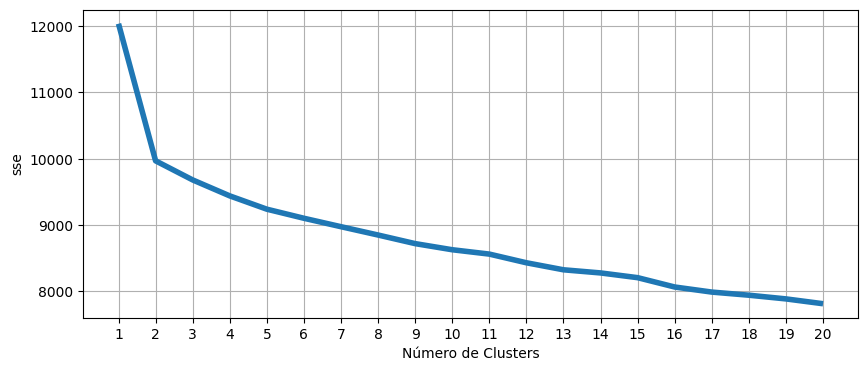

In [20]:
# Identificação do número ótimo de clusters pelo Método de Elbow
# Adaptado de https://realpython.com/k-means-clustering-python/

sse = []
for k in range(1,21):
    kmeans = KMeans(n_clusters = k, n_init = 10, init = 'k-means++', max_iter = 100, random_state = 1)
    kmeans.fit(matriz_tfidf_ementa_svd)
    sse.append(kmeans.inertia_)

fig, ax = plt.subplots(figsize=(10, 4))
plt.style.use("fivethirtyeight")
plt.grid(True)
plt.plot(range(1, 21), sse)
plt.xticks(range(1, 21))
plt.xlabel("Número de Clusters")
plt.ylabel("sse")
plt.show()



In [21]:
# Instalação da Library kneed para calcular, programaticamente, o número ótimo de clusters
# Adaptado de https://realpython.com/k-means-clustering-python/

!pip install kneed

In [22]:
from kneed import KneeLocator

kl = KneeLocator(range(1, 21), sse, curve="convex", direction="decreasing")
print("Número de Clusters sugerido pelo kneelocator: ", kl.elbow)

Número de Clusters sugerido pelo kneelocator:  4


In [23]:
# Implementação do K-Means para a feature "ementa", já stemmerizada, utilizando o nro. ótimo de clusters

nro_clusters = kl.elbow
kmeans = KMeans(n_clusters = nro_clusters, n_init = 10, init = 'k-means++', max_iter = 300, random_state = 1)
arr_clusters = kmeans.fit_predict(matriz_tfidf_ementa_svd)
d_clusters = {'cluster': arr_clusters + 1, # somando 1 para começar do cluster 1
              'AIIM': decisoes_df['AIIM'],
              #'Data publicação': decisoes_df['data_pub'],
              'ano_pub': decisoes_df['ano_pub']
              }
df_clusters = pd.DataFrame(d_clusters, columns = ['cluster', 'AIIM', 'ano_pub'])
labels = kmeans.labels_
labels
df_clusters

,cluster,AIIM,ano_pub
0,3,3161064-0,2015
1,3,4029507-2,2015
2,1,3129058-9,2015
3,3,3128037-7,2015
4,3,3157786-6,2015
...,...,...,...
32141,3,5051047-2,2025
32142,3,5050805-2,2025
32143,3,3106590-9,2025
32144,3,4130102-0,2025


In [24]:
# Acrescentar a feature "cluster_ementa" ao DataFrame

# Remover colunas duplicadas que podem ter sido criadas em execuções anteriores
decisoes_df.drop(columns=['cluster_ementa_x', 'cluster_ementa_y', 'cluster_ementa'], inplace=True, errors='ignore')

df_labels = pd.DataFrame(labels, columns = ['cluster_ementa'])
decisoes_df.reset_index(drop = True, inplace = True)
decisoes_df = pd.merge(decisoes_df, df_labels, how = 'inner', left_index = True, right_index = True)
decisoes_df['cluster_ementa'] = decisoes_df['cluster_ementa'].astype('str')

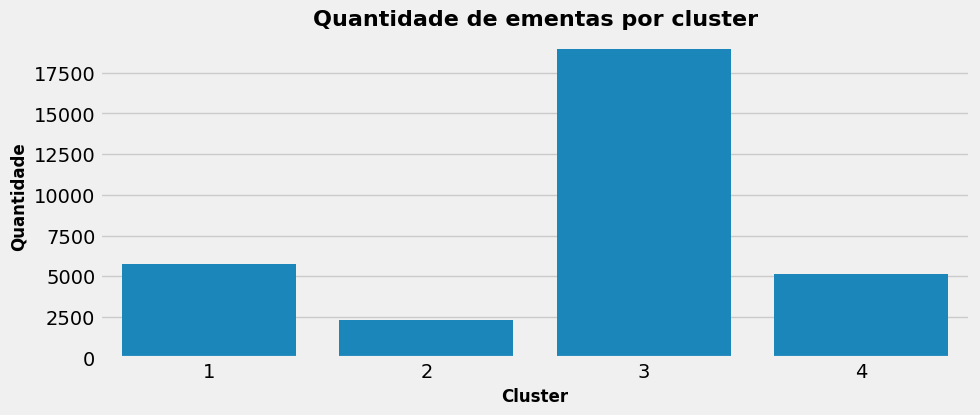

In [25]:
# Visualizando ementas por cluster

fig, ax = plt.subplots(figsize=(10, 4))
sns.countplot(x='cluster', data=df_clusters)
plt.title("Quantidade de ementas por cluster", fontsize = 16, fontweight = 'bold')
ax.set_xlabel('Cluster', fontsize = 12, fontweight = 'bold')
ax.set_ylabel('Quantidade', fontsize = 12, fontweight = 'bold')
plt.show()

### Avaliação dos resultados da clusterização "ementa_stem"

In [26]:
!pip install wordcloud

cluster:  1
Contagem de decisões:  5761


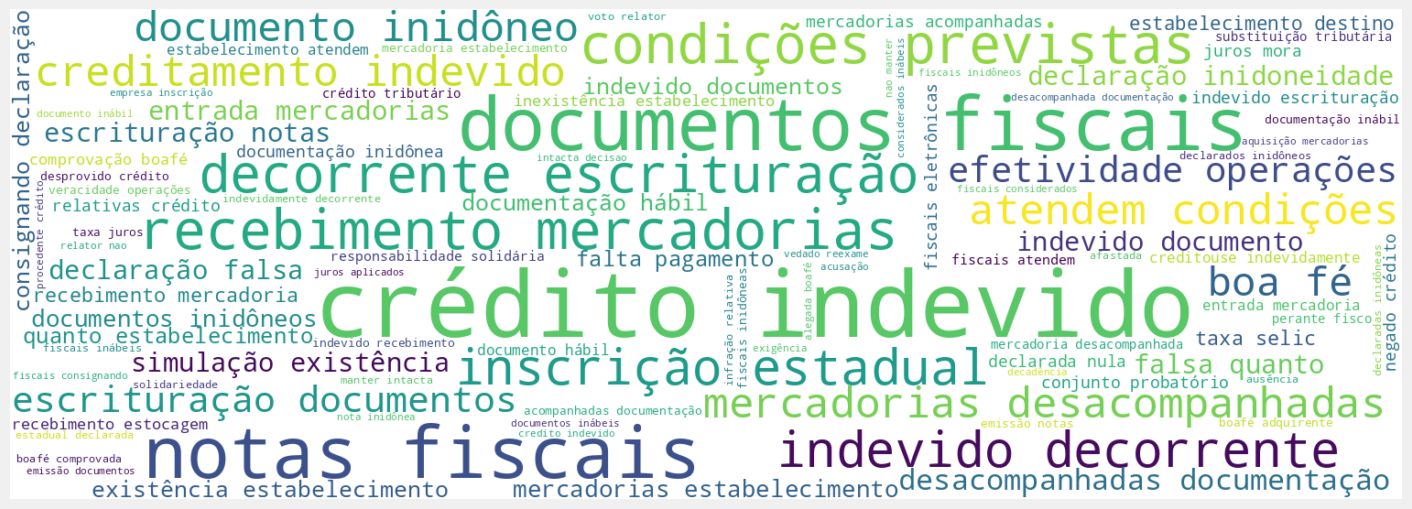

cluster:  2
Contagem de decisões:  2298


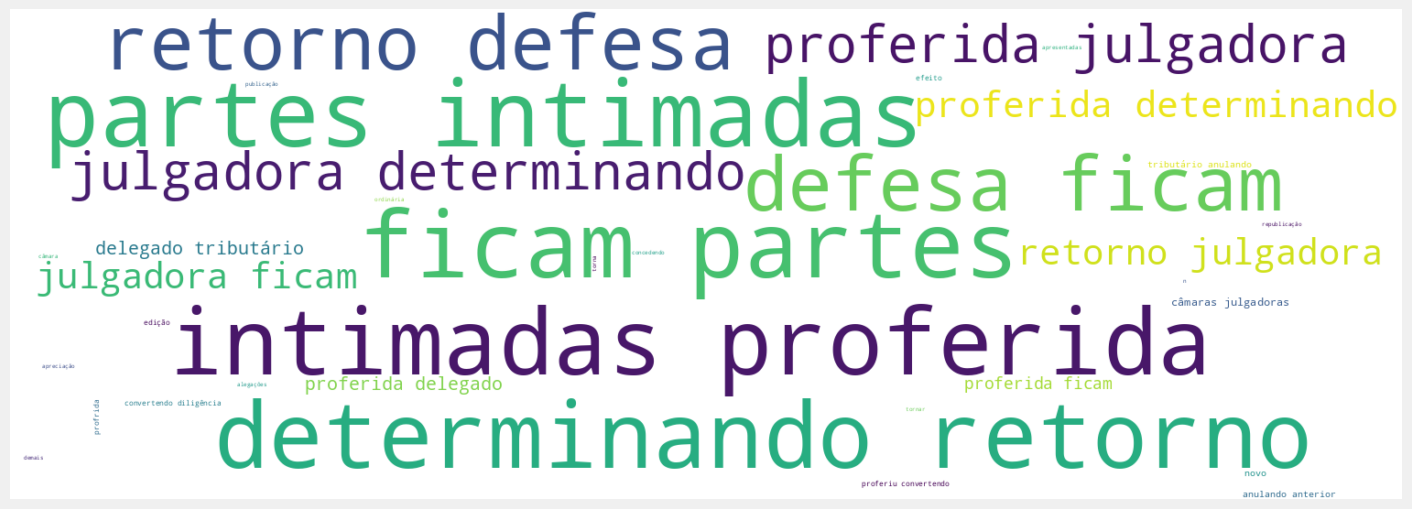

cluster:  3
Contagem de decisões:  18957


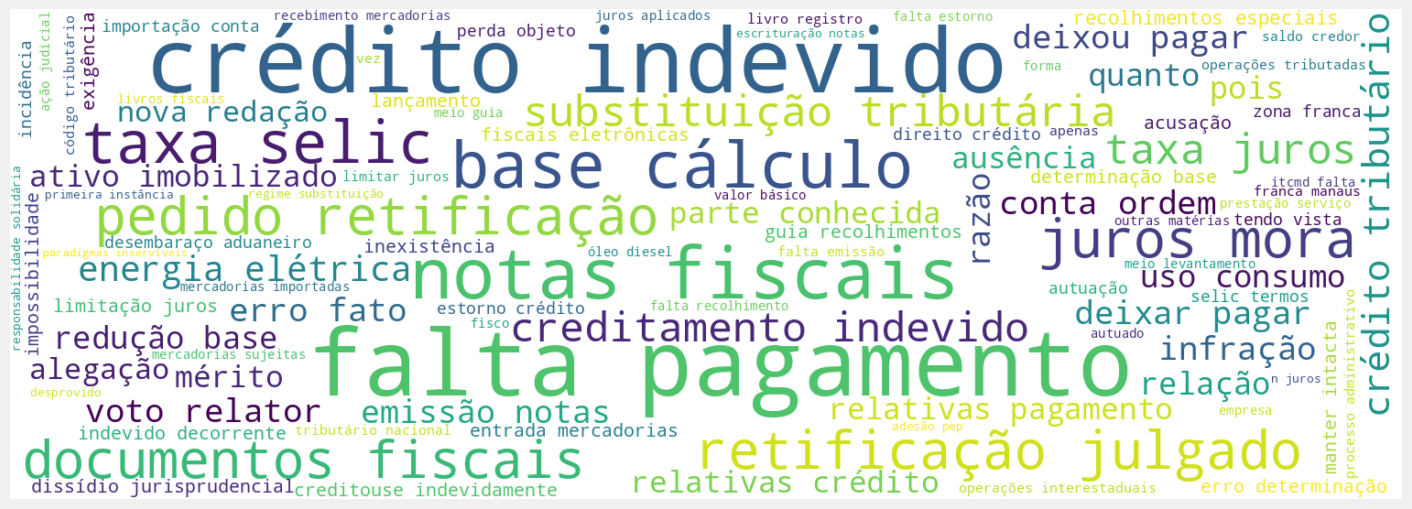

cluster:  4
Contagem de decisões:  5130


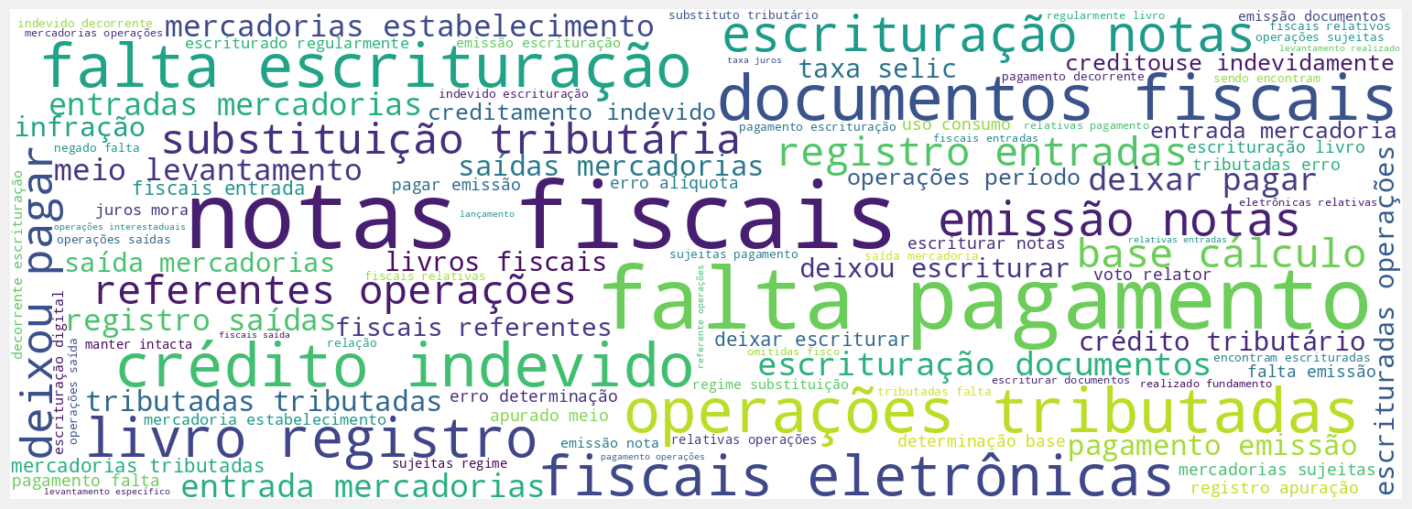

In [27]:
from wordcloud import WordCloud

# Constrói a Wordcloud
result = {'cluster': labels, 'ementa': decisoes_df['ementa_clean']}
result = pd.DataFrame(result)
for k in range(0, nro_clusters):
   s = result[result['cluster'] == k]
   text = s['ementa'].str.cat(sep=' ')
   text = text.lower()
   text = ' '.join([word for word in text.split()])
   wordcloud = WordCloud(max_font_size = 100, width = 1520, height = 535, max_words = 100,
                         colormap = 'viridis', background_color = "white", collocations=True, normalize_plurals=False)
   wordcloud.generate(text)

   print("cluster: ", k + 1) #só pra manter a nomenclatura de cluster 0 = cluster 1
   print("Contagem de decisões: ", len(s)) # Adiciona a contagem de decisões

   plt.figure(figsize = (16,9))
   plt.imshow(wordcloud, interpolation="bilinear")
   plt.axis("off")
   plt.show()

In [28]:
# Determinação dos termos mais frequentes de cada cluster
# limpa stopwo

CV = CountVectorizer()

df_termos_freq = pd.DataFrame()

for i in range(0, nro_clusters):
    matriz_contagens = CV.fit_transform(decisoes_df[decisoes_df['cluster_ementa'] == str(i)]['ementa_clean'])
    df_cont_pal = pd.DataFrame(CV.get_feature_names_out(), columns = ['palavra'])
    df_cont_pal['cluster_ementa'] = i + 1
    df_cont_pal['freq'] = matriz_contagens.sum(axis = 0).tolist()[0]

    # remove stopwords - filtro. cria df_remove, e pelo index remove a stopword
    for stopword in stopwords_ajustado:
        df_remove = df_cont_pal[df_cont_pal['palavra'] == stopword]
        df_cont_pal.drop(labels = df_remove.index, inplace = True)

    df_cont_pal.sort_values(['freq'], ascending = False, inplace = True)
    df_termos_freq = pd.concat([df_termos_freq, df_cont_pal[0:20]]) #Só armazena os 20 termos mais frequentes em cada cluster

df_termos_freq

,palavra,cluster_ementa,freq
1621,crédito,1,3920
3545,indevido,1,3854
2966,fiscais,1,3595
2237,documentos,1,3328
4266,mercadorias,1,3076
...,...,...,...
2907,entrada,4,1763
3100,estabelecimento,4,1624
4786,livro,4,1620
2088,deixou,4,1594


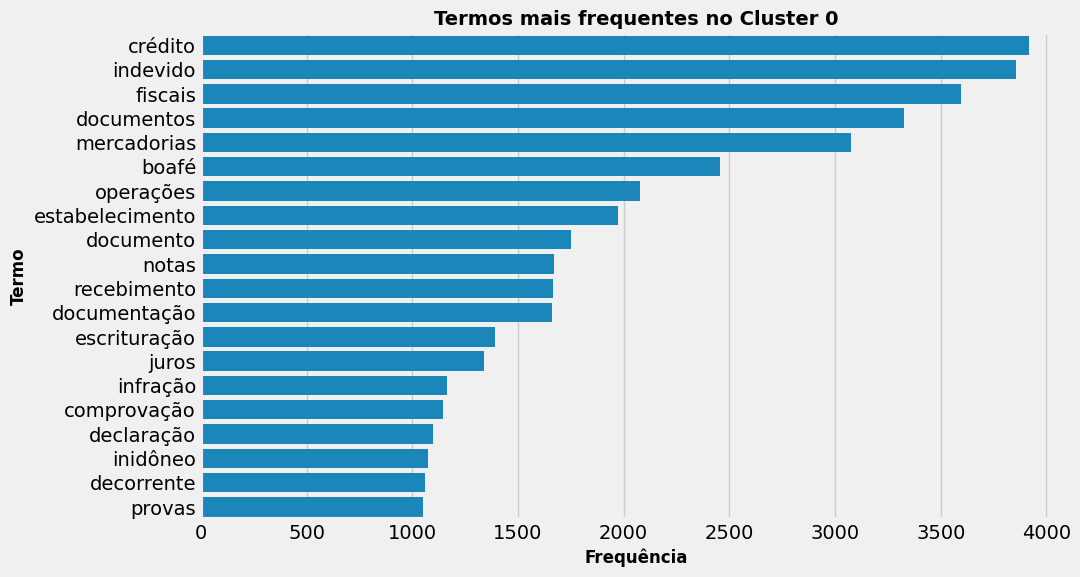

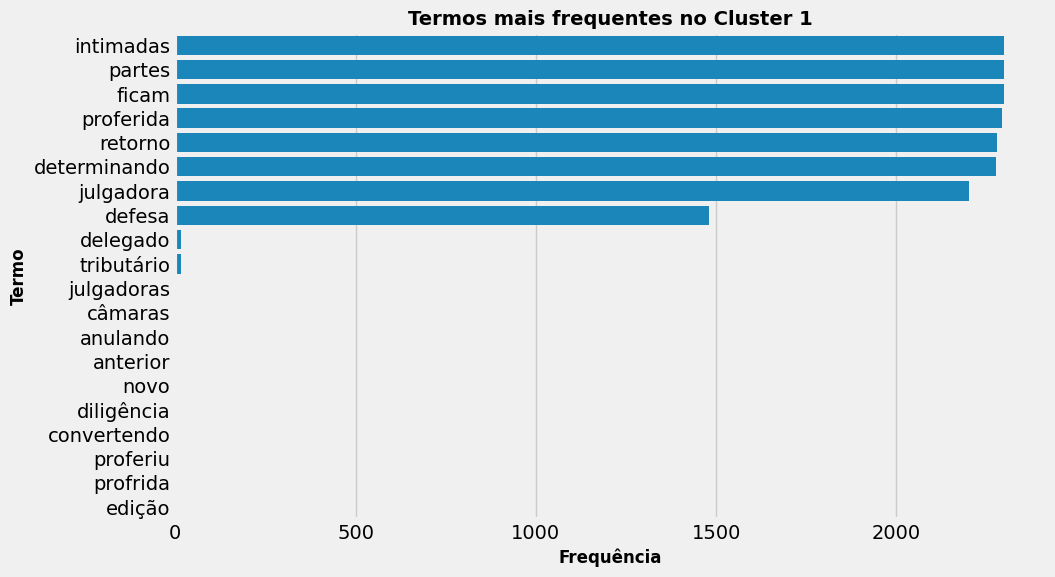

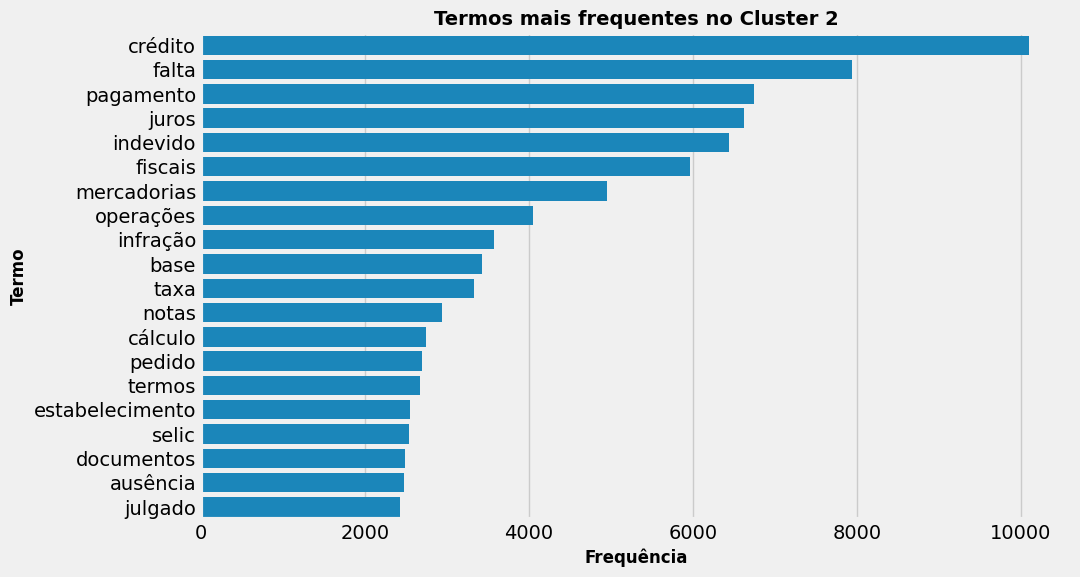

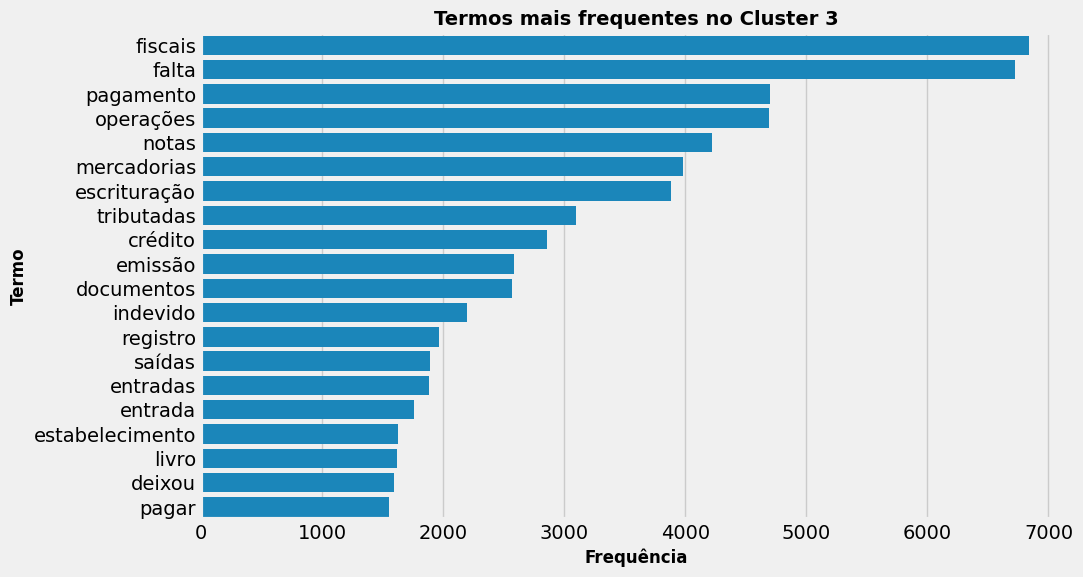

In [29]:
# Plotagem de gráficos com os termos mais frequentes por cluster

for i in range(nro_clusters):
    fig, ax = plt.subplots(figsize=(10,6))
    plt.title('Termos mais frequentes no Cluster {}'.format(i), fontsize=14, fontweight='bold')
    sns.barplot(data=df_termos_freq[df_termos_freq['cluster_ementa'] == i+1], x='freq', y='palavra', orient='h')
    ax.set_xlabel('Frequência', fontsize=12, fontweight='bold')
    ax.set_ylabel('Termo', fontsize=12, fontweight='bold')
    plt.show()

o número de cluster pelo knee method não mostrou muita diferenciação quanto ao mérito (assunto) dos casos.

Há um cluster grande que inclui a maioria dos assuntos, enquantos outros demonstram aspectos processuais (retorno, anulação).

Diagnóstico: somente pelo TF-IDF + Knee locator, não temos um bom resultado.

## Novos Métodos
1º -> Spacy e POS (Part of Speech)


In [30]:
import spacy

# Install spaCy
!pip install spacy

# Download the Portuguese large model for spaCy
# This might take a few minutes the first time it's run
!python -m spacy download pt_core_news_lg

# You can then load the model for use
nlp = spacy.load('pt_core_news_lg')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 568.2/568.2 MB 3.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [31]:
#

In [32]:
nlp = spacy.load('pt_core_news_lg')

# Gerar embeddings para a coluna 'ementa_clean'
decisoes_df['ementa_embeddings'] = decisoes_df['ementa_clean'].apply(lambda text: nlp(text).vector)

# Exibir as primeiras 5 linhas com a nova coluna de embeddings
display(decisoes_df[['ementa_clean', 'ementa_embeddings']].head())

,ementa_clean,ementa_embeddings
0,acusação recebimento crédito condição estabele...,"[-0.74210453, -0.62183994, -0.58766234, -1.026..."
1,falta pagamento referente saldo devedor transf...,"[-1.0718633, -0.93504524, -0.6095929, -0.55522..."
2,crédito indevido documento inidôneo infração d...,"[-0.6240954, -1.0071311, -0.36510056, -0.69261..."
3,falta pagamento apurada meio levantamento real...,"[-0.46086255, -1.1682707, -0.33911267, -0.6781..."
4,creditamento indevido falta comprovação origem...,"[-1.7078819, -1.134596, -0.20259134, -0.407681..."


In [33]:
# Instala a biblioteca transformers se ainda não estiver instalada
!pip install transformers

# Importa as classes necessárias do transformers
from transformers import AutoTokenizer, AutoModel

# Define o nome do modelo RoBERTaLexPT
roberta_model_name = 'eduagarcia/RoBERTaLexPT-base'

# Carrega o tokenizer e o modelo
tokenizer_roberta = AutoTokenizer.from_pretrained(roberta_model_name)
model_roberta = AutoModel.from_pretrained(roberta_model_name)

print(f"Modelo RoBERTaLexPT '{roberta_model_name}' e Tokenizer carregados com sucesso.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/642 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: eduagarcia/RoBERTaLexPT-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Modelo RoBERTaLexPT 'eduagarcia/RoBERTaLexPT-base' e Tokenizer carregados com sucesso.


In [34]:
import spacy

# Certifique-se de que o modelo 'pt_core_news_lg' está carregado
nlp = spacy.load('pt_core_news_lg')

def extract_ngrams_candidates(text):
    # Processa o texto com o modelo spaCy
    doc = nlp(text)

    # Filtra tokens que são substantivos, nomes próprios ou adjetivos
    # e que não são stopwords ou pontuação, usando o lema para normalização
    relevant_tokens = [
        token.lemma_.lower() for token in doc
        if token.pos_ in ['NOUN', 'PROPN', 'ADJ']
        and not token.is_stop
        and not token.is_punct
        and token.lemma_.lower() not in stopwords_ajustado # Verifica contra stopwords personalizadas
    ]

    ngrams = []
    # Gera bigrams (sequências de 2 palavras)
    for i in range(len(relevant_tokens) - 1):
        bigram = f"{relevant_tokens[i]} {relevant_tokens[i+1]}"
        ngrams.append(bigram)

    # Gera trigrams (sequências de 3 palavras)
    for i in range(len(relevant_tokens) - 2):
        trigram = f"{relevant_tokens[i]} {relevant_tokens[i+1]} {relevant_tokens[i+2]}"
        ngrams.append(trigram)

    # Inclui também os tokens relevantes individuais (unigrams)
    ngrams.extend(relevant_tokens)

    # Retorna uma lista de n-grams únicos
    return list(set(ngrams))

# Aplica a função à coluna 'ementa_clean' para gerar os n-grams candidatos
decisoes_df['ementa_ngrams'] = decisoes_df['ementa_clean'].apply(extract_ngrams_candidates)

# Exibe as primeiras linhas do DataFrame com a nova coluna de n-grams
display(decisoes_df[['ementa_clean', 'ementa_ngrams']].head())

,ementa_clean,ementa_ngrams
0,acusação recebimento crédito condição estabele...,"[pagamento subitem objeto, efeito, condição es..."
1,falta pagamento referente saldo devedor transf...,"[n pagamento integral, n pagamento, parcelamen..."
2,crédito indevido documento inidôneo infração d...,"[inidôneo infração fisco, fisco contraprovo, c..."
3,falta pagamento apurada meio levantamento real...,"[débito crédito, administrativo questionamento..."
4,creditamento indevido falta comprovação origem...,"[benefício n liquidação, parcela, pagamento in..."


da análise dos n-grams, ementa_clean parece NÃO ser uma boa ideia...

In [35]:
# Aplica a função à coluna 'ementa' para gerar os n-grams candidatos
decisoes_df['ementa_raw_ngrams'] = decisoes_df['ementa'].apply(extract_ngrams_candidates)



In [36]:
display(decisoes_df[['ementa', 'ementa_raw_ngrams']].head())


,ementa,ementa_raw_ngrams
0,aiim icms - acusação de recebimento de crédito...,"[efeito, condição estabelecimento, subitem nºs..."
1,falta de pagamento do imposto referente ao sal...,"[centralizador i.1 crédito, i.1 crédito saldo,..."
2,icms. crédito indevido. documento inidôneo. in...,"[inidôneo infração fisco, contraprova questão,..."
3,icms. falta de pagamento do icms apurada por m...,"[débito crédito, administrativo questionamento..."
4,icms – creditamento indevido – falta de compro...,"[indever comprovação, parcela, pagamento integ..."


In [37]:
'''
De acordo com os modelos avaliados por Giarelis (como EmbedRank, Key2Vec, WordAttractionRank e SIFRank),
 a regra de Regex mais bem-sucedida e padronizada é configurar a expressão para capturar sequências formadas
 exclusivamente por substantivos ou por adjetivos seguidos de substantivos (formando as chamadas noun phrases).
'''
from spacy.matcher import Matcher

# 1. Carrega o pipeline do spaCy em português
nlp = spacy.load("pt_core_news_lg")

# 2. Processa o seu documento (a sua ementa)
texto = "A multa grave e a penalidade pecuniária foram aplicadas após a infração."
doc = nlp(texto)

# 3. Inicializa o Matcher com o vocabulário do modelo
matcher = Matcher(nlp.vocab)

# 4. Define o sequenciamento (Regex de POS).
# A regra abaixo busca: Adjetivo (opcional) + Substantivo (obrigatório, pode ser mais de um) + Adjetivo (opcional)
padrao = [
    {"POS": "ADJ", "OP": "*"},   # Zero ou mais adjetivos
    {"POS": "NOUN", "OP": "+"},  # Um ou mais substantivos
    {"POS": "ADJ", "OP": "*"}    # Zero ou mais adjetivos
]

matcher.add("PADRAO_SUBST_ADJ", [padrao])

# 5. Extrai as expressões-chave candidatas
matches = matcher(doc)
candidatos_extraidos = []

for match_id, inicio, fim in matches:
    span = doc[inicio:fim] # O n-gram encontrado
    candidatos_extraidos.append(span.text)

print(set(candidatos_extraidos))
# Retornará: {'penalidade pecuniária', 'infração', 'multa grave'}


{'infração', 'penalidade', 'penalidade pecuniária', 'multa', 'multa grave'}


In [38]:
from spacy.matcher import Matcher

# Certifique-se de que o modelo 'pt_core_news_lg' está carregado
nlp = spacy.load('pt_core_news_lg')

def extract_pos_ngrams(text):
    doc = nlp(text)
    matcher = Matcher(nlp.vocab)

    # Padrão: Adjetivo (opcional) + Substantivo (obrigatório, pode ser mais de um) + Adjetivo (opcional)
    pattern = [
        {"POS": "ADJ", "OP": "*"},
        {"POS": "NOUN", "OP": "+"},
        {"POS": "ADJ", "OP": "*"}
    ]

    matcher.add("NOUN_PHRASE", [pattern])

    matches = matcher(doc)
    extracted_ngrams = []

    for match_id, start, end in matches:
        span = doc[start:end]
        # Opcional: Filtrar n-grams que são apenas stopwords ou muito curtos
        if len(span.text.split()) > 1 and span.text.lower() not in stopwords_ajustado:
             # Remover n-grams que são apenas números ou caracteres especiais
            if any(char.isalpha() for char in span.text):
                extracted_ngrams.append(span.text.lower())

    # Adiciona unigrams (substantivos e adjetivos relevantes) que não estejam contidos nos n-grams já extraídos
    for token in doc:
        if token.pos_ in ['NOUN', 'ADJ'] and not token.is_stop and not token.is_punct and token.text.lower() not in stopwords_ajustado:
            lemma = token.lemma_.lower()
            if any(char.isalpha() for char in lemma):
                is_part_of_ngram = False
                for ngram in extracted_ngrams:
                    if lemma in ngram:
                        is_part_of_ngram = True
                        break
                if not is_part_of_ngram:
                    extracted_ngrams.append(lemma)


    return list(set(extracted_ngrams))

# Aplica a função à coluna 'ementa_clean'
decisoes_df['ementa_clean_pos_ngrams'] = decisoes_df['ementa_clean'].apply(extract_pos_ngrams)

# Exibe as primeiras linhas do DataFrame com a nova coluna de n-grams
display(decisoes_df[['ementa_clean', 'ementa_clean_pos_ngrams']].head())

,ementa_clean,ementa_clean_pos_ngrams
0,acusação recebimento crédito condição estabele...,"[efeito, tributário, recebimento crédito condi..."
1,falta pagamento referente saldo devedor transf...,"[n pagamento integral, n pagamento, renúncia d..."
2,crédito indevido documento inidôneo infração d...,"[trabalho alegação caráter confiscatório, cont..."
3,falta pagamento apurada meio levantamento real...,"[prática infracional, débito crédito, válidas ..."
4,creditamento indevido falta comprovação origem...,"[liquidação débito, integral parcela, origem p..."
